In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../music-sources-unified'))
if module_path not in sys.path: sys.path.append(module_path)
import unify_lib as uni

import time
import pandas as pd
from pprint import pprint
import ytmusicapi as ytmusicapi
from fuzzywuzzy import fuzz
import re
DATE = time.strftime('%m-%d-%Y')
print(DATE)
PLAYLIST_MAX_SIZE=5000

MIN_ALBUM_LEN = 3
ALBUM_LIKE_MIN_PROBA = 0.7

MB_LIB = '../db_assets/musicbee_library.tsv'
MB_INBOX = '../db_assets/musicbee_inbox.tsv'
YT_TRACK_DB = '../../ytmusic/playlists/_tracks_db.tsv'
HEADER_FILE='../../ytmusic/headers_auth.json'

yt_res_cache = {}
yt_unmatched_cache = {}
yt_album_track_cache = {}



12-15-2022


## Load musicbee and ytmusic databases

In [2]:
print('YTMUSIC')
print(f'Using ytmusicapi version: {ytmusicapi.__version__}')
print(f'Using header file: {HEADER_FILE}')
yt = ytmusicapi.YTMusic(HEADER_FILE)


print(f'Using yt db file: {YT_TRACK_DB}')
yt_db = pd.read_csv(YT_TRACK_DB, sep='\t', index_col=0)
print(f"Loaded {len(yt_db)} ytmusic db entries.")

## library
print('\nMUSICBEE LIBRARY')
print(f'Using musicbee db file: {MB_LIB}')
mb_lib = pd.read_csv(MB_LIB, sep='\t')
mb_lib['fuzzy_id'] = mb_lib.apply(uni.make_musicbee_fuzzy_id, axis=1)
mb_lib['fuzzy_album_id'] = mb_lib.apply(uni.make_mb_fuzzy_album_id, axis=1)
mb_lib = mb_lib.loc[~mb_lib['Path'].str.endswith('.asx')]  # ignore asx files
print(f"Loaded {len(mb_lib)} musicbee db entries.")

## inbox
print('\nMUSICBEE INBOX')
print(f'Using musicbee db file: {MB_INBOX}')
mb_inb = pd.read_csv(MB_INBOX, sep='\t')
mb_inb['fuzzy_id'] = mb_inb.apply(uni.make_musicbee_fuzzy_id, axis=1)
mb_inb['fuzzy_album_id'] = mb_inb.apply(uni.make_mb_fuzzy_album_id, axis=1)
mb_inb = mb_inb.loc[~mb_inb['Path'].str.endswith('.asx')]  # ignore asx files
print(f"Loaded {len(mb_inb)} musicbee db entries.")

# downloads subset
print('\nMUSICBEE DOWNLOADS')
mb_dld = mb_inb.loc[mb_inb['Path'].str.contains('Downloads')]
print(f"Loaded {len(mb_dld)} musicbee db entries.")


YTMUSIC
Using ytmusicapi version: 0.24.1
Using header file: ../../ytmusic/headers_auth.json
Using yt db file: ../../ytmusic/playlists/_tracks_db.tsv
Loaded 135327 ytmusic db entries.

MUSICBEE LIBRARY
Using musicbee db file: ../db_assets/musicbee_library.tsv
Loaded 54756 musicbee db entries.

MUSICBEE INBOX
Using musicbee db file: ../db_assets/musicbee_inbox.tsv
Loaded 42667 musicbee db entries.

MUSICBEE DOWNLOADS
Loaded 5193 musicbee db entries.


## Choose Year and Filter MB

In [62]:

YEAR = 2017

mb = pd.concat([mb_lib, mb_dld])
mb = mb.loc[mb['Year'] == str(YEAR)]
print(f'{len(mb)} entries from {YEAR}')


293 entries from 2017


## Organize musicbee albums

In [63]:
# Build database of musicbee albums
def get_album_dict(df):
  # most of these take the most common value for all tracks in album
  album_dict = {
    'album_artist': pd.concat([df['Artist'], df['Album Artist']]).value_counts().index[0],
    'album': df['Album'].value_counts().index[0],
    'year': uni.parse_mb_year(df['Year'].value_counts().index[0]),
    'rating_mean': round(df['Rating'].sum()/len(df), 2),
    'like_probability': round(len(df['Rating'].loc[df['Rating'] > 3])/len(df['Rating']), 2), 
    'total_track_playcount': df['Play Count'].sum(), 
    'total_tracks': len(df), 
    'genre': ''
  }
  if len(df['Genre'].dropna()): # some albums dont have genre
    album_dict['genre'] = df['Genre'].value_counts().index[0]
  return album_dict

mb_album_data = {}
for album_id, df in mb.groupby('fuzzy_album_id'):
  if len(df) < MIN_ALBUM_LEN:
    continue
  mb_album_data[album_id] = get_album_dict(df)
  
mb_album_data = pd.DataFrame(mb_album_data).T
print(f'{len(mb_album_data)} entries from {YEAR}')

24 entries from 2017


## Search ytmusic for musicbee albums and fuzz check matches

In [64]:
_matched_entries = []
_unmatched_entries = []
for i, (album_key, album) in enumerate(mb_album_data.iterrows()):
    prog = f'({i}/{len(mb_album_data)})'
    # Check cache for saved YTMusic query response or previous match failures        
    if album_key in yt_res_cache:
        match = yt_res_cache[album_key]
    elif album_key in yt_unmatched_cache:
        print(f'Skipping: previously unmatched album: {album_key}')
        continue
    # Query YTMusic
    else:
        match = album.to_dict()
        album_query = f'{album.album_artist} - {album.album}'
        # if album.year: album_query += f' {album.year}'
        try:
            # print(f'searching for {album_query}')
            res = yt.search(query=album_query, filter='albums', limit=1)
            if len(res):
                res = res[0]
                match['is_album'] = True
                match['ytmusic_title'] = ''
                match['ytmusic_album'] = res.get('title', '')
                match['ytmusic_albumId'] = res.get('browseId', '')
                if 'artists' in res:
                    match['ytmusic_artist'] = res['artists'][0].get('name', '')
                    match['ytmusic_artistId'] = res['artists'][0].get('id', '')
                match['ytmusic_key'] = f"{match.get('ytmusic_artist', '').lower()} - {match.get('ytmusic_album', '')}"
            
        except Exception as e:
            print(f'Error with query {album_query}: {e}')
            pass

        # Store unmatched ytmusic query
        if len(res) == 0:
            unmatch = album.to_dict()
            unmatch['manual_label'] = 'no-match'
            yt_unmatched_cache[album_key] = unmatch
            _unmatched_entries.append(unmatch)
            print(f'Skipping unmatched: {album_query}')
            continue

        # Other ytmusic fields
        # match['ytmusic_entry'] = f"{match.get('ytmusic_artist', '')} - {match.get('ytmusic_title', '')} - {match.get('ytmusic_album', '')}"
        match['ytmusic_duration'] = res['duration']
        match['ytmusic_year'] = res['year']
        match['ytmusic_resultType'] = res['resultType']
        yt_res_cache[album_key] = match

    # Musicbee fields
    match['musicbee_key'] = album_key
    match['manual_label'] = f'no-label_{DATE}'

    # Match Score
    try:
        scores = uni.extract_match_scores(
            match['musicbee_key'], match['ytmusic_key'])
        for sk, sv in scores.items():
            match[f'match_score_{sk}'] = sv
        # Using manual grading to set thresholds
        if scores['token_sort_ratio'] < 40 or scores['token_set_ratio'] < 60:
            match['match_quality'] = 0.
        elif scores['token_sort_ratio'] > 75 or scores['token_set_ratio'] > 75:
            match['match_quality'] = 1.
        else:
            match['match_quality'] = 0.5
    except Exception as e:
        match['match_quality'] = 0.0
        print(f'Skipping match score for {album_query}.\n  Match Error: {e}')

    # Update match results
    _matched_entries.append(match)
    print(f"{prog} {match['match_quality']} match for {album_query}\ttoken_sort_ratio={scores['token_sort_ratio']}\ttoken_set_ratio={scores['token_set_ratio']}")

# Process Matched entries
_match_df = pd.DataFrame(_matched_entries)
_match_file = f'../logs/musicbee_{YEAR}_yt_album_matches_{DATE}.tsv'
_match_df.to_csv(_match_file, sep='\t', header=True)

# Process Unmatched entries
_unmatch_df = pd.DataFrame(_unmatched_entries)
_unmatch_file = f'../logs/musicbee_{YEAR}_yt_album_failed_matches_{DATE}.tsv'
_unmatch_df.to_csv(_unmatch_file, sep='\t', header=True)


(0/24) 1.0 match for All Them Witches - Sleeping Through the War	token_sort_ratio=100	token_set_ratio=100
(1/24) 1.0 match for alt-J - Relaxer	token_sort_ratio=100	token_set_ratio=100
(2/24) 1.0 match for Brockhampton - SATURATION I II III	token_sort_ratio=92	token_set_ratio=100
(3/24) 1.0 match for BROCKHAMPTON - SATURATION II	token_sort_ratio=100	token_set_ratio=100
(4/24) 1.0 match for BROCKHAMPTON - SATURATION III	token_sort_ratio=100	token_set_ratio=100
(5/24) 1.0 match for bsd.u - pook	token_sort_ratio=100	token_set_ratio=100
(6/24) 0.5 match for Daphni - Joli Mai	token_sort_ratio=61	token_set_ratio=61
(7/24) 1.0 match for Ducktails - Jersey Devil	token_sort_ratio=100	token_set_ratio=100
(8/24) 1.0 match for eevee - eevee beat tape 02	token_sort_ratio=86	token_set_ratio=100
(9/24) 1.0 match for El Michels Affair - Return to the 37th Chamber	token_sort_ratio=81	token_set_ratio=92
(10/24) 1.0 match for Her's - Songs of Her's	token_sort_ratio=100	token_set_ratio=100
(11/24) 1.0 matc

## Manually check matches and set bad matches to 0 in place before next steps

In [65]:
_match_df = _match_df[_match_df['match_quality'] == 1.0]

## Process Matches add to ytmusic playlists

In [66]:
print(f"Number of albums > {ALBUM_LIKE_MIN_PROBA} like probability: {len(mb_album_data['like_probability'].loc[mb_album_data['like_probability'] > ALBUM_LIKE_MIN_PROBA])}")
yt_album_matches = []
yt_tracks = []
yt_album_liked = []
mb_album_need_like = []
_year_playlists  = {}
_top_albums_playlist = []
for i, (alb_i, album) in enumerate(_match_df.iterrows()):
    
    # Format current album dict
    album['liked_album'] = bool(album['like_probability'] > ALBUM_LIKE_MIN_PROBA)
    album['genre_main'] = str(album['genre']).split(';')[0]
    album['year_playlist'] = uni.get_album_year_playlist(album['year'])
    if album['year_playlist'] not in _year_playlists:
        _year_playlists[album['year_playlist']] = []
    album['musicbee_tracks'] = []
    album['ytmusic_tracks'] = []

    # Get ytmusic album entry
    if album['ytmusic_albumId'] in yt_album_track_cache:
        yt_album = yt_album_track_cache[album['ytmusic_albumId']]
    else:
        yt_album = yt.get_album(album['ytmusic_albumId'])['tracks']
        yt_album_track_cache[album['ytmusic_albumId']] = yt_album
    
    # Get musicbee album entry
    mb_album = mb.loc[mb['fuzzy_album_id'] == album['musicbee_key']].copy()
    mb_ids = mb_album.apply(uni.make_musicbee_fuzzy_track_id, axis=1)
    mb_album['fuzzy_track_id'] = mb_ids

    # Loop through album tracks
    for yt_track in yt_album:
        yt_track = uni.clean_up_album_track(yt_track)

        # check if mb has match like
        yt_track['fuzzy_track_id'] = uni.get_fuzzy_track_id(yt_track['title'], yt_track['artist'])
        query, result, score = uni.query_search_pool(yt_track['fuzzy_track_id'], list(mb_ids), scorer=fuzz.ratio)
        mb_track = mb_album.loc[mb_album['fuzzy_track_id'] == result].iloc[0].to_dict()
        
        # TODO if yt liked add to add to prexisting genre playlist based on album['genre_main']
        # Compare musicbee and ytmusic LIKE status
        mb_is_like = bool(mb_track['Rating'] > 3.5)
        yt_is_like = bool(yt_track['likeStatus'] == 'LIKE')
        if not mb_is_like and yt_is_like:
            mb_album_need_like.append(mb_track['Path'])
        if mb_is_like and not yt_is_like:
            yt.rate_song(yt_track['videoId'], rating='LIKE')
            yt_album_liked.append(yt_track['videoId'])
            _year_playlists[album['year_playlist']].append(yt_track['videoId'])
            yt_is_like = True

        if album['liked_album']:
            _top_albums_playlist.append(yt_track['videoId'])
        album['musicbee_tracks'].append(mb_track)
        album['ytmusic_tracks'].append(yt_track)
        yt_tracks.append(yt_track['videoId'])
        
    prog = f'({i}/{len(_match_df)})'
    print(f"{prog} {album['album']} - {album['album_artist']}")
    yt_album_matches.append(album)
    
print(f"{len(yt_album_matches)} musicbee matches found on ytmusic")



Number of albums > 0.7 like probability: 1
(0/21) Sleeping Through the War - All Them Witches
(1/21) Relaxer - alt-J
(2/21) SATURATION I II III - Brockhampton
(3/21) SATURATION II - BROCKHAMPTON
(4/21) SATURATION III - BROCKHAMPTON
(5/21) pook - bsd.u
(6/21) Jersey Devil - Ducktails
(7/21) eevee beat tape 02 - eevee
(8/21) Return to the 37th Chamber - El Michels Affair
(9/21) Songs of Her's - Her's
(10/21) Love What Survives - Mount Kimbie
(11/21) XP +1 - OKOKKO
(12/21) Being So Normal - Peach Pit
(13/21) The Weather - Pond
(14/21) Vault Vol. 1 - STRFKR
(15/21) Rapper's Best Friend 4: An Instrumental Series - The Alchemist
(16/21) Death Song - The Black Angels
(17/21) Superclean Vol. I - The Marías
(18/21) Old Locomotive - The Murlocs
(19/21) Mister Mellow - Washed Out
(20/21) Is Everything Okay in Your World? - Yellow Days
21 musicbee matches found on ytmusic


In [67]:
DRY = False 
MB_LIKE_M3U=f'../m3u/musicbee_{YEAR}_thumbs_up_from_ytmusic_{DATE}.m3u'

print(f"{len(mb_album_need_like)} NOT liked musicbee matches liked on ytmusic")
if not DRY:
    pd.Series(mb_album_need_like).dropna().to_csv(MB_LIKE_M3U, sep='\t', header=False, index=False)

print(f"\n{len(yt_tracks)} matched ytmusic {YEAR} tracks, making library playlists of size {PLAYLIST_MAX_SIZE}")
for i, start in enumerate(range(0, len(yt_tracks), PLAYLIST_MAX_SIZE)):
    end = min(start+PLAYLIST_MAX_SIZE, len(yt_tracks))
    vids = yt_tracks[start:end]
    print(f" {i+1} {start}:{end} musicbee {YEAR} album tracks")
    if not DRY:
        yt.create_playlist(
            title=f'y_{YEAR}_musicbee_albums_part_{i+1}',
            description=f'part {i} for musicbee {YEAR} album tracks',
            video_ids=vids
        )


39 NOT liked musicbee matches liked on ytmusic

262 matched ytmusic 2017 tracks, making library playlists of size 5000
 1 0:262 musicbee 2017 album tracks


## musicbee Album Stats

In [25]:
N=20
print(N,'top genres\n', mb_album_data['genre'].value_counts().head(N))


20 top genres
                       25
Indie                  6
Hip Hop                3
Rock                   3
Electronic             3
Alternative            2
Rap/Hip Hop            1
Lo-Fi                  1
Acoustic               1
R&B                    1
psychedelic/ indie     1
Funk                   1
Ambient Dub            1
Psychedelic Rock       1
Psychedelic            1
Dream Pop              1
Pop / Electronic       1
Reggae/Dub             1
House/UK Garage        1
Punk Rock              1
Name: genre, dtype: int64


In [28]:
mb_album_data['like_probability'].loc[mb_album_data['like_probability'] > 0.5 ]

built to spill - when the wind forgets your name     1.0
burial - streetlands                                0.67
duster - together                                   0.54
fontaines d.c. - skinty fia                          0.6
gold panda - the work                                1.0
Name: like_probability, dtype: object

count    64.000000
mean      0.597187
std       0.937317
min       0.000000
25%       0.000000
50%       0.000000
75%       0.972500
max       3.780000
Name: rating_mean, dtype: float64


<AxesSubplot: title={'center': '2022 Albums by Mean Rating (out of 5)'}, ylabel='Frequency'>

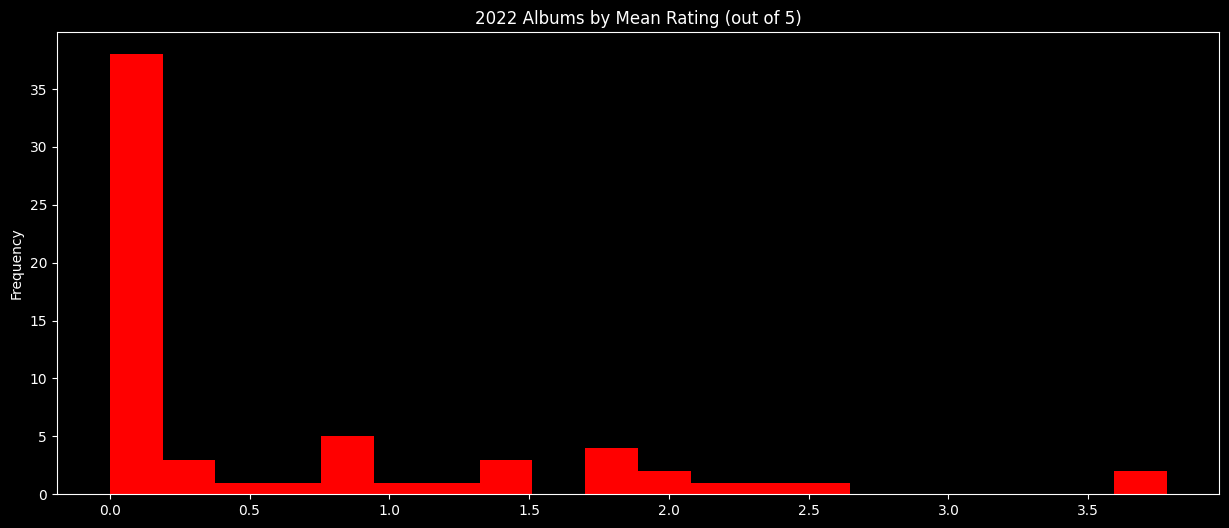

In [34]:
print(mb_album_data['rating_mean'].astype(float).describe())
mb_album_data['rating_mean'].astype(float).plot.hist(bins=20, figsize=(15, 6), color='r', title=f'{YEAR} Albums by Mean Rating (out of 5)')


<AxesSubplot: title={'center': '2022 Albums by Playcount Total'}, ylabel='Frequency'>

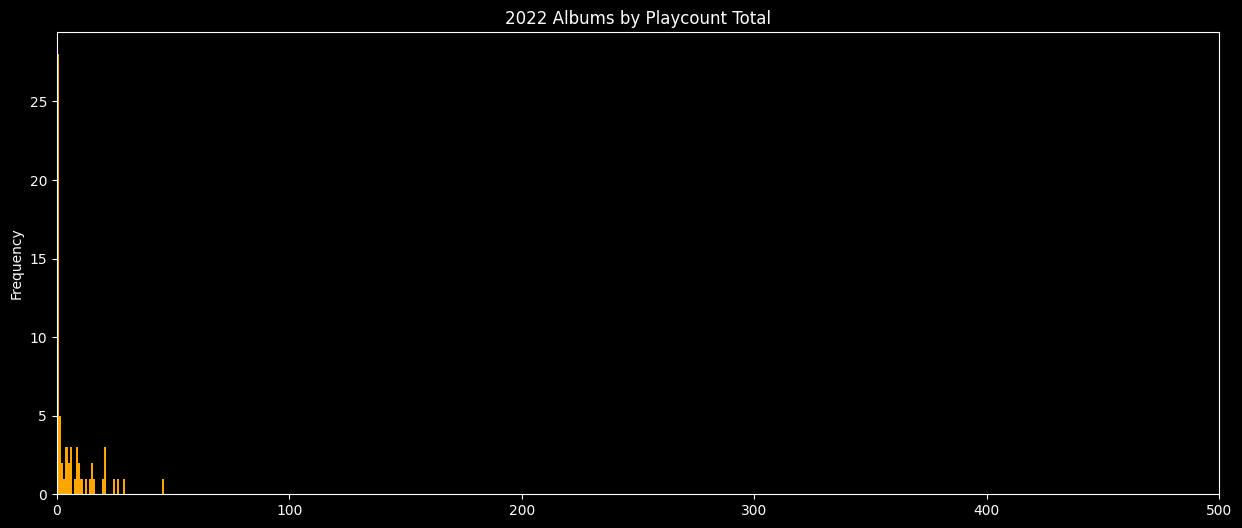

In [31]:
mb_album_data['total_track_playcount'].plot.hist(bins=50, xlim=(0, 500), figsize=(15, 6), color='orange', title=f'{YEAR} Albums by Playcount Total')